code chunk to plot igf2bp2 expression levels and correlation between igf2bp2 and nr1d2 from all the datasets analyzed for rhythmicity

order of datasets:

Mouse
GSE197726 

GSE194106

GSE273878

GSE308276

GSE107787

GSE195724

Humans:
GSE182117

GSE109825

GSE108539


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from statsmodels.nonparametric.smoothers_lowess import lowess
import os
from matplotlib.lines import Line2D


## GSE197726

In [2]:
# ----------------------------
# 1️⃣ Load data
# ----------------------------
file = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/output_text_files/07_filtered_counts/gse197726_normalized_counts.tsv"
df = pd.read_csv(file, sep="\t")

# rename first column
df = df.rename(columns={'Unnamed: 0': 'gene_name'})

print(df)

                gene_name  WT-ZT-0-1  WT-ZT-0-2  WT-ZT-0-5  WT-ZT-4-1  \
0      ENSMUSG00000000001   8.895228   9.317688   9.140491   9.050536   
1      ENSMUSG00000000028   6.669076   6.717470   6.615394   6.548462   
2      ENSMUSG00000000031  13.016334  13.616053  12.738332  12.549161   
3      ENSMUSG00000000056  11.636501  11.438936  11.713025  11.583106   
4      ENSMUSG00000000058   9.392120   9.499168   9.389182   9.393428   
...                   ...        ...        ...        ...        ...   
13913  ENSMUSG00002076601  10.584554  10.138057  10.286161  10.072795   
13914  ENSMUSG00002076650  13.269331  12.194281  12.549500  12.008032   
13915  ENSMUSG00002076696   8.376504   7.606010   7.676871   7.650634   
13916  ENSMUSG00002076809   9.182457   8.179125   9.027538   8.464513   
13917  ENSMUSG00002076896   7.653852   7.046761   7.514809   6.991091   

       WT-ZT-4-2  WT-ZT-4-5  WT-ZT-8-1  WT-ZT-8-3  WT-ZT-8-5  ...  mRE-ZT-8-5  \
0       9.190647   9.004700   8.970804   9

In [3]:
# ----------------------------
# 2️⃣ Choose gene
# ----------------------------
gene_name = "ENSMUSG00000033581"  # ENSMUSG00000055116 Bmal1 , ENSMUSG00000021775 Nr1d2 , ENSMUSG00000033581 Igf2bp2 # change this to any gene

gene_df = df[df["gene_name"] == gene_name]

# ----------------------------
# 3️⃣ Convert to long format
# ----------------------------
long = gene_df.melt(id_vars="gene_name",
                    var_name="sample",
                    value_name="expression")

# extract genotype
long["genotype"] = long["sample"].str.split("-").str[0]

# extract ZT time
long["ZT"] = long["sample"].str.extract(r'ZT-(\d+)').astype(int)

In [4]:
# ----------------------------
# 4️⃣ Calculate mean and SEM
# ----------------------------
summary = long.groupby(["genotype","ZT"])["expression"].agg(
    mean="mean",
    sem=lambda x: np.std(x, ddof=1)/np.sqrt(len(x))
).reset_index()


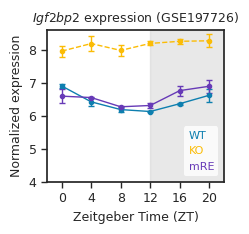

In [25]:
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# seaborn style
sns.set_theme(style="ticks")

# ----------------------------
# 5️⃣ Plot
# ----------------------------
colors = {
    "WT": "#0E7FAF",
    "KO": "#fbbc05",
    "mRE": "#673ab7"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12, 24, color="lightgrey", alpha=0.5)

rhythmic_status = {
    "WT": "rhythmic",
    "KO": "arrhythmic",
    "mRE": "rhythmic"
}

for genotype in ["WT","KO","mRE"]:
    
    sub = summary[summary["genotype"] == genotype].sort_values("ZT")
    
    linestyle = "--" if rhythmic_status[genotype] == "arrhythmic" else "-"
    
    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[genotype],
        linestyle=linestyle
    )

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2, 22)
plt.yticks(range(4,9, 1), fontsize=9)

plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized expression", fontsize=9)

legend_elements = [
    Line2D([0], [0], color=colors["WT"], lw=0, label="WT"),
    Line2D([0], [0], color=colors["KO"], lw=0, label="KO"),
    Line2D([0], [0], color=colors["mRE"], lw=0, label="mRE")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    loc="lower right",
    fontsize=8
)

for text, genotype in zip(legend.get_texts(), ["WT","KO","mRE"]):
    text.set_color(colors[genotype])

plt.tick_params(direction="out", length=4, width=1)

plt.title(r"$\it{Igf2bp2}$ expression (GSE197726)", fontsize=9)

plt.tight_layout()

# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE197726_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE197726_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE197726_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)

plt.show()

In [19]:
# -------------------------
# extract genes
# -------------------------
igf = df[df["gene_name"] == "ENSMUSG00000033581"].iloc[0]
nr1d2 = df[df["gene_name"] == "ENSMUSG00000021775"].iloc[0]

# -------------------------
# define groups
# -------------------------
groups = {
    "WT": [c for c in df.columns if c.startswith("WT-")],
    "KO": [c for c in df.columns if c.startswith("KO-")],
    "mRE": [c for c in df.columns if c.startswith("mRE-")]
}

# -------------------------
# build correlation dataframe
# -------------------------
records = []

for g, cols in groups.items():

    for col in cols:

        igf_val = float(igf[col])
        nr_val = float(nr1d2[col])

        records.append({
            "Igf2bp2": igf_val,
            "Nr1d2": nr_val,
            "Genotype": g
        })

corr_df = pd.DataFrame(records)

print(corr_df.head())
print(corr_df["Genotype"].value_counts())

    Igf2bp2      Nr1d2 Genotype
0  6.825341  11.170404       WT
1  6.937874  11.115594       WT
2  6.989294  11.313745       WT
3  6.591052  11.590935       WT
4  6.521703  11.750632       WT
Genotype
WT     18
KO     18
mRE    18
Name: count, dtype: int64


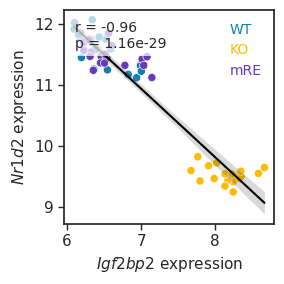

In [9]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.stats import pearsonr
# from matplotlib.lines import Line2D

# # position of correlation text (easy to move)
# r_pos_x = 0.05
# r_pos_y = 0.95

# plt.figure(figsize=(3,3))

# sns.scatterplot(
#     data=corr_df,
#     x="Igf2bp2",
#     y="Nr1d2",
#     hue="Genotype",
#     palette=colors,
#     s=35,
#     legend=False
# )

# sns.regplot(
#     data=corr_df,
#     x="Igf2bp2",
#     y="Nr1d2",
#     scatter=False,
#     line_kws={"color":"black","linewidth":1.5},
#     ci=95
# )

# # compute correlation
# r, p = pearsonr(corr_df["Nr1d2"], corr_df["Igf2bp2"])

# # movable annotation
# plt.text(
#     r_pos_x,
#     r_pos_y,
#     f"r = {r:.2f}\np = {p:.2e}",
#     transform=plt.gca().transAxes,
#     fontsize=10,
#     verticalalignment="top",
#     bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
# )

# # italic labels
# plt.xlabel(r"$\it{Igf2bp2}$ expression", fontsize=11)
# plt.ylabel(r"$\it{Nr1d2}$ expression", fontsize=11)

# # journal-style ticks
# plt.tick_params(direction="out", length=4, width=1)

# # legend text only
# legend_elements = [
#     Line2D([0],[0],color=colors["WT"],lw=0,label="WT"),
#     Line2D([0],[0],color=colors["KO"],lw=0,label="KO"),
#     Line2D([0],[0],color=colors["mRE"],lw=0,label="mRE")
# ]

# legend = plt.legend(
#     handles=legend_elements,
#     frameon=True,
#     facecolor="white",
#     edgecolor="none",
#     handlelength=0,
#     handletextpad=0,
#     loc="upper right",
#     fontsize=10
# )

# for text, genotype in zip(legend.get_texts(), ["WT","KO","mRE"]):
#     text.set_color(colors[genotype])

# plt.tight_layout()
# plt.show()

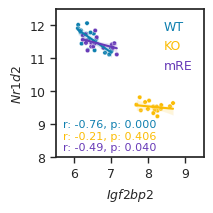

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

colors = {
    "WT": "#0E7FAF",
    "KO": "#fbbc05",
    "mRE": "#673ab7"
}

# position of r/p block (EDIT THESE TO MOVE TEXT)
rpx = 5.7
rpy = 8.9
line_spacing = 0.35

fig, ax = plt.subplots(figsize=(2.3,2.3))

sns.scatterplot(
    data=corr_df,
    x="Igf2bp2",
    y="Nr1d2",
    hue="Genotype",
    palette=colors,
    s=10,
    legend=False,
    ax=ax
)

# regression lines
for genotype in ["WT","KO","mRE"]:
    
    sub = corr_df[corr_df["Genotype"] == genotype]

    sns.regplot(
        data=sub,
        x="Igf2bp2",
        y="Nr1d2",
        scatter=False,
        line_kws={"color":colors[genotype],"linewidth":1.5},
        ax=ax
    )

ax.set_xlabel(r"$\it{Igf2bp2}$",fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$",fontsize=9)

ax.tick_params(direction="out", length=4, width=1,labelsize=9)

# ticks
ax.set_xlim(5.5,9.5)
ax.set_xticks(np.arange(6,10,1))

ax.set_ylim(8,12.5)
ax.set_yticks(np.arange(8,12.5,1))

# custom legend
legend_elements = [
    Line2D([0],[0],color=colors["WT"],lw=0,label="WT"),
    Line2D([0],[0],color=colors["KO"],lw=0,label="KO"),
    Line2D([0],[0],color=colors["mRE"],lw=0,label="mRE")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=9
)

for text, genotype in zip(legend.get_texts(), ["WT","KO","mRE"]):
    text.set_color(colors[genotype])

# r and p values (movable)
for i, genotype in enumerate(["WT","KO","mRE"]):
    
    sub = corr_df[corr_df["Genotype"] == genotype]
    r, p = pearsonr(sub["Igf2bp2"], sub["Nr1d2"])

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[genotype],
        fontsize=8
    )

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE197726_igf2bp2_nr1d2_corr.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE197726_igf2bp2_nr1d2_corr.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE197726_igf2bp2_nr1d2_corr.svg", bbox_inches="tight", transparent=True)


plt.show()

## GSE194106

In [2]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE194106/GSE194106_RNAseq-muscle-tpm.txt"
df = pd.read_csv(file_path, sep="\t")

print(df)

          geneID    GasD00_1    GasD00_2    GasD00_3    GasD00_4    GasD04_1  \
0         497097    3.879338    4.990513    2.550108    1.834277    1.390392   
1          19888    2.533132    2.109692    4.659280    2.453637    2.954143   
2          20671   50.791778   39.202107   52.490761   47.861529   45.867976   
3          27395   46.954021   46.213247   44.875500   46.083853   46.918249   
4          18777   65.459083   63.702056   62.552723   64.436418   64.300806   
...          ...         ...         ...         ...         ...         ...   
19067  108168747  155.603898  165.114992  164.882995  148.721528  157.132477   
19068  102633420    0.000000    0.000000    2.773377    2.921083    2.909152   
19069  108167801    0.000000    2.940856    0.000000    0.000000    2.909152   
19070  108168252    3.296183    0.000000    0.000000    5.754454    2.909152   
19071  105244086   77.554360   84.674172  106.313027   86.180068  103.986743   

         GasD04_2    GasD04_3    GasD04

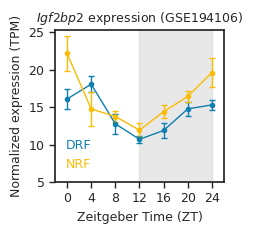

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from scipy.stats import sem

sns.set_theme(style="ticks")

# -------------------------
# 2️⃣ Extract gene
# -------------------------
gene_id = "319765"
gene_row = df[df["geneID"].astype(str) == str(gene_id)]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Collect TPM values
# -------------------------
pattern = re.compile(r"Gas([DN])(\d+)_\d+")

data_dict = {}

for col in df.columns:

    match = pattern.match(col)

    if match:
        group_letter = match.group(1)
        time = int(match.group(2))

        group = "DRF" if group_letter == "D" else "NRF"

        raw_value = float(gene_row[col].values[0])

        if group not in data_dict:
            data_dict[group] = {}

        if time not in data_dict[group]:
            data_dict[group][time] = []

        data_dict[group][time].append(raw_value)

# -------------------------
# 4️⃣ Compute mean and SEM
# -------------------------
summary_rows = []

for group in data_dict:

    for time in sorted(data_dict[group].keys()):

        values = data_dict[group][time]

        summary_rows.append({
            "group": group,
            "time": time,
            "mean": np.mean(values),
            "sem": sem(values)
        })

summary = pd.DataFrame(summary_rows)

# -------------------------
# 5️⃣ Plot
# -------------------------
colors = {
    "DRF": "#0E7FAF",
    "NRF": "#fbbc05"
}

rhythmic_status = {
    "DRF": "rhythmic",
    "NRF": "rhythmic"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12, 24, color="lightgrey", alpha=0.5)

for group in ["DRF", "NRF"]:

    sub = summary[summary["group"] == group].sort_values("time")
    
    linestyle = "--" if rhythmic_status[group] == "arrhythmic" else "-"
    
    plt.errorbar(
        sub["time"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[group],
        linestyle=linestyle
    )

# -------------------------
# Axis styling
# -------------------------
plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized expression (TPM)", fontsize=9)

plt.xticks(sorted(summary["time"].unique()), fontsize=9)

plt.yticks(np.arange(5, 30, 5), fontsize=9)

plt.xlim(-2, 26)

plt.tick_params(direction="out", length=4, width=1)

# -------------------------
# Legend (colored text)
# -------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0],[0],color=colors["DRF"],lw=0,label="DRF"),
    Line2D([0],[0],color=colors["NRF"],lw=0,label="NRF")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=9
)

for text, group in zip(legend.get_texts(), ["DRF","NRF"]):
    text.set_color(colors[group])

plt.title(r"$\it{Igf2bp2}$ expression (GSE194106)", fontsize=9)
plt.tight_layout()


# # save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE194106_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE194106_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE194106_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)


plt.show()

In [174]:
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE194106/GSE194106_RNAseq-muscle-tpm.txt"

df = pd.read_csv(file_path, sep="\t", index_col=0)

In [175]:
print(df.columns[:36])
print(df.head())

Index(['GasD00_1', 'GasD00_2', 'GasD00_3', 'GasD00_4', 'GasD04_1', 'GasD04_2',
       'GasD04_3', 'GasD04_4', 'GasD08_1', 'GasD08_2', 'GasD08_3', 'GasD08_4',
       'GasD12_1', 'GasD12_2', 'GasD12_3', 'GasD12_4', 'GasD16_1', 'GasD16_2',
       'GasD16_3', 'GasD16_4', 'GasD20_1', 'GasD20_2', 'GasD20_3', 'GasD20_4',
       'GasD24_1', 'GasD24_2', 'GasD24_3', 'GasD24_4', 'GasN00_1', 'GasN00_2',
       'GasN00_3', 'GasN00_4', 'GasN04_1', 'GasN04_2', 'GasN04_3', 'GasN04_4'],
      dtype='object')
         GasD00_1   GasD00_2   GasD00_3   GasD00_4   GasD04_1   GasD04_2  \
geneID                                                                     
497097   3.879338   4.990513   2.550108   1.834277   1.390392   1.975372   
19888    2.533132   2.109692   4.659280   2.453637   2.954143   0.977818   
20671   50.791778  39.202107  52.490761  47.861529  45.867976  46.025523   
27395   46.954021  46.213247  44.875500  46.083853  46.918249  47.123559   
18777   65.459083  63.702056  62.552723  64.436

In [176]:
df.index = df.index.astype(str)

In [177]:
igf2bp2 = df.loc["319765"]
nr1d2 = df.loc["353187"]

In [178]:
gasd_cols = [c for c in df.columns if str(c).startswith("GasD")]
gasn_cols = [c for c in df.columns if str(c).startswith("GasN")]

print("GASD samples:", len(gasd_cols))
print("GASN samples:", len(gasn_cols))

GASD samples: 28
GASN samples: 28


In [179]:
print(df.columns[:20])
print(gasd_cols[:5])

Index(['GasD00_1', 'GasD00_2', 'GasD00_3', 'GasD00_4', 'GasD04_1', 'GasD04_2',
       'GasD04_3', 'GasD04_4', 'GasD08_1', 'GasD08_2', 'GasD08_3', 'GasD08_4',
       'GasD12_1', 'GasD12_2', 'GasD12_3', 'GasD12_4', 'GasD16_1', 'GasD16_2',
       'GasD16_3', 'GasD16_4'],
      dtype='object')
['GasD00_1', 'GasD00_2', 'GasD00_3', 'GasD00_4', 'GasD04_1']


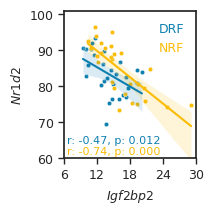

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

colors = {
    "GASD": "#0E7FAF",
    "GASN": "#fbbc05"
}

# position of r/p block
rpx = 6.5
rpy = 64
line_spacing = 3

fig, ax = plt.subplots(figsize=(2.3,2.3))

# scatter points
for group, cols in {"GASD": gasd_cols, "GASN": gasn_cols}.items():

    x = igf2bp2[cols].astype(float)
    y = nr1d2[cols].astype(float)

    sns.scatterplot(
        x=x,
        y=y,
        color=colors[group],
        s=10,
        legend=False,
        ax=ax
    )

# regression lines
for group, cols in {"GASD": gasd_cols, "GASN": gasn_cols}.items():

    x = igf2bp2[cols].astype(float)
    y = nr1d2[cols].astype(float)

    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        line_kws={"color":colors[group], "linewidth":1.5},
        ax=ax
    )

ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=9)

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# axis limits
ax.set_xlim(6,30)
ax.set_xticks(np.arange(6,31,6))

ax.set_ylim(60,101)
ax.set_yticks(np.arange(60,101,10))

# legend (colored text)
legend_elements = [
    Line2D([0],[0],color=colors["GASD"],lw=0,label="DRF"),
    Line2D([0],[0],color=colors["GASN"],lw=0,label="NRF")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=9
)

for text, group in zip(legend.get_texts(), ["GASD","GASN"]):
    text.set_color(colors[group])

# r and p annotation
for i, (group, cols) in enumerate({"GASD": gasd_cols, "GASN": gasn_cols}.items()):

    x = igf2bp2[cols].astype(float)
    y = nr1d2[cols].astype(float)

    r, p = pearsonr(x, y)

    label = "DRF" if group == "GASD" else "NRF"
    
    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[group],
        fontsize=8
    )

plt.tight_layout()

# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE194106_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE194106_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE194106_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)

plt.show()

## GSE273878

In [33]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE273878/GSE273878_gene_fpkm.xls"
df = pd.read_csv(file_path,sep="\t")
print(df)

                  gene_id        SW00_1        SW00_2        KW00_1  \
0      ENSMUSG00000064351  29926.269025  27197.852367  29410.991798   
1      ENSMUSG00000031972  24083.024584  25750.942345  25729.778410   
2      ENSMUSG00000064341  19831.239246  19161.966549  21002.359826   
3      ENSMUSG00000064370  18994.267331  18416.020716  19654.008052   
4      ENSMUSG00000064345  14798.501852  13823.211874  15567.181438   
...                   ...           ...           ...           ...   
56743  ENSMUSG00002075400      0.000000      0.000000      0.000000   
56744  ENSMUSG00002074970      0.000000      0.000000      0.000000   
56745  ENSMUSG00002075729      0.000000      0.000000      0.000000   
56746  ENSMUSG00002074899      0.000000      0.000000      0.000000   
56747  ENSMUSG00002076890      0.000000      0.000000      0.000000   

             KW00_2        SM00_1        SM00_2        KM00_1        KM00_2  \
0      26202.569766  30306.917396  28130.454872  33790.824914  27226

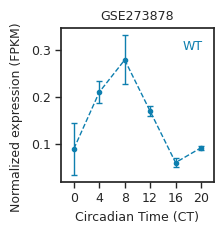

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import sem
from matplotlib.lines import Line2D

# seaborn style
sns.set_theme(style="ticks")

# -------------------------
# 2️⃣ Extract gene by Ensembl ID
# -------------------------
gene_id = "ENSMUSG00000033581"
gene_row = df[df["gene_id"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Extract Sw columns   #SW = WT_CTL, KW = WT_KPC, SM = KO_CTL, KM = KO_KPC
# -------------------------
pattern = re.compile(r"SW(\d+)_\d+")

data_dict = {}

for col in df.columns:
    match = pattern.match(col)
    if match:
        time = int(match.group(1))
        value = float(gene_row[col].values[0])

        if time not in data_dict:
            data_dict[time] = []

        data_dict[time].append(value)

# -------------------------
# Compute mean ± SEM
# -------------------------
times = sorted(data_dict.keys())
means = np.array([np.mean(data_dict[t]) for t in times])
sems = np.array([sem(data_dict[t]) for t in times])

# -------------------------
# Plot
# -------------------------
colors = {"WT": "#0E7FAF"}

plt.figure(figsize=(2.5,2.5))

plt.errorbar(
    times,
    means,
    yerr=sems,
    marker='o',
    markersize=3,
    linewidth=1,
    capsize=2,
    color=colors["WT"],
    linestyle="--"   # dashed line for arrhythmic gene

)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Circadian Time (CT)", fontsize=9)
plt.ylabel("Normalized expression (FPKM)", fontsize=9)

ax = plt.gca()
ax.yaxis.set_label_coords(-0.25, 0.42)


plt.xticks(times, fontsize=9)
plt.xlim(-2, 22)

plt.yticks(fontsize=9)

plt.tick_params(direction="out", length=4, width=1)

# legend (colored text only)
legend_elements = [
    Line2D([0], [0], color=colors["WT"], lw=0, label="WT")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=9
)

for text in legend.get_texts():
    text.set_color(colors["WT"])

plt.title("GSE273878", fontsize=9)
plt.tight_layout()


# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE273878_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE273878_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE273878_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)



plt.show()

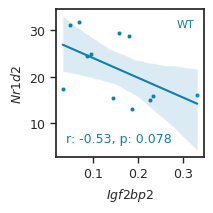

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import pearsonr

sns.set_theme(style="ticks")

# -------------------------
# Extract genes
# -------------------------
igf_id = "ENSMUSG00000033581"
nr1d2_id = "ENSMUSG00000021775"

igf_row = df[df["gene_id"] == igf_id]
nr1d2_row = df[df["gene_id"] == nr1d2_id]

if igf_row.empty or nr1d2_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# Extract SW columns 
# -------------------------
pattern = re.compile(r"SW(\d+)_\d+")

cols = [c for c in df.columns if pattern.match(c)]

# -------------------------
# Prepare correlation vectors
# -------------------------
x = igf_row[cols].values.flatten().astype(float)
y = nr1d2_row[cols].values.flatten().astype(float)

# -------------------------
# Correlation
# -------------------------
r, p = pearsonr(x, y)

# r/p annotation position
rpx = 0.04
rpy = 6

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(2.3,2.3))

sns.scatterplot(
    x=x,
    y=y,
    color="#0E7FAF",
    s=10,
    legend=False,
    ax=ax
)

sns.regplot(
    x=x,
    y=y,
    scatter=False,
    line_kws={"color":"#0E7FAF","linewidth":1.5},
    ax=ax
)

ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=9)

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# r/p annotation
ax.text(
    rpx,
    rpy,
    f"r: {r:.2f}, p: {p:.3f}",
    color="#0E7FAF",
    fontsize=9
)


legend_elements = [
    Line2D([0], [0], color="#0E7FAF", lw=0, label="WT")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text in legend.get_texts():
    text.set_color("#0E7FAF")

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE273878_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE273878_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE273878_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)


plt.show()

## GSE308276

In [36]:
# -------------------------
# 1️⃣ Load Excel
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE308276/GSE308276_FPKM_mus_from_WT_and_Bmal1LKO_6tp.xlsx"
df = pd.read_excel(file_path)
print(df)

             GeneSym  B1: WT_ZT0_REP1  B2: WT_ZT0_REP2  B3: WT_ZT0_REP3  \
0      0610005C13Rik         0.229328          0.05984         0.245940   
1      0610007P14Rik         2.916400          3.37841         2.437520   
2      0610009B22Rik        39.209300         39.15340        36.533300   
3      0610009L18Rik        37.816100         44.48480        49.026900   
4      0610009O20Rik        46.930800         51.63950        43.714300   
...              ...              ...              ...              ...   
24314         Zyg11a         0.814088          0.49651         0.269376   
24315         Zyg11b        14.621600         12.35190        10.688700   
24316            Zyx        14.467500         13.29690        11.998500   
24317          Zzef1         2.894960          2.73511         2.596810   
24318           Zzz3         4.171100          4.46781         4.540930   

       B4: WT_ZT4_REP1  B5: WT_ZT4_REP2  B6: WT_ZT4_REP3  B7: WT_ZT8_REP1  \
0             0.081670

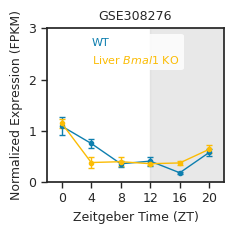

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# 2️⃣ Extract gene
# -------------------------
gene_symbol = "Igf2bp2"
gene_row = df[df["GeneSym"] == gene_symbol]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Extract WT / KO data
# -------------------------
pattern = re.compile(r"(WT|KO)_ZT(\d+)_REP\d+")

data = []

for col in df.columns:

    match = pattern.search(col)

    if match:

        genotype = match.group(1)
        time = int(match.group(2))
        value = float(gene_row[col].values[0])

        data.append((genotype, time, value))

data = pd.DataFrame(data, columns=["genotype","ZT","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["genotype","ZT"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Plot
# -------------------------
colors = {
    "WT": "#0E7FAF",
    "KO": "#fbbc05"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12, 24, color="lightgrey", alpha=0.5)

for genotype in ["WT","KO"]:

    sub = summary[summary["genotype"] == genotype].sort_values("ZT")

    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[genotype]
    )

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2, 22)

plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized Expression (FPKM)", fontsize=9)

ax = plt.gca()


ax.set_ylim(0,3)
ax.set_yticks(np.arange(0,4,1))

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# -------------------------
# Legend
# -------------------------
legend_elements = [
    Line2D([0],[0],color=colors["WT"],lw=0,label=r"WT"), #($\it{Bmal1}^{wt/wt}$)"),
    Line2D([0],[0],color=colors["KO"],lw=0,label=r"Liver $\it{Bmal1}$ KO") #($\it{Bmal1}^{hep-/-}$)")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8,loc="upper center"
)

for text, genotype in zip(legend.get_texts(), ["WT","KO"]):
    text.set_color(colors[genotype])

plt.title("GSE308276", fontsize=9)
plt.tight_layout()

# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE308276_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE308276_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE308276_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)

plt.show()

In [38]:
##correlation 

# -------------------------
# 1️⃣ Load Excel
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE308276/GSE308276_FPKM_mus_from_WT_and_Bmal1LKO_6tp.xlsx"
df = pd.read_excel(file_path, index_col=0)
print(df)


               B1: WT_ZT0_REP1  B2: WT_ZT0_REP2  B3: WT_ZT0_REP3  \
GeneSym                                                            
0610005C13Rik         0.229328          0.05984         0.245940   
0610007P14Rik         2.916400          3.37841         2.437520   
0610009B22Rik        39.209300         39.15340        36.533300   
0610009L18Rik        37.816100         44.48480        49.026900   
0610009O20Rik        46.930800         51.63950        43.714300   
...                        ...              ...              ...   
Zyg11a                0.814088          0.49651         0.269376   
Zyg11b               14.621600         12.35190        10.688700   
Zyx                  14.467500         13.29690        11.998500   
Zzef1                 2.894960          2.73511         2.596810   
Zzz3                  4.171100          4.46781         4.540930   

               B4: WT_ZT4_REP1  B5: WT_ZT4_REP2  B6: WT_ZT4_REP3  \
GeneSym                                        

In [39]:
# remove "B1: " prefix
df.columns = [c.split(": ")[1] for c in df.columns]

# clean gene names
df.index = df.index.astype(str).str.strip().str.upper()

print(df.columns[:5])



Index(['WT_ZT0_REP1', 'WT_ZT0_REP2', 'WT_ZT0_REP3', 'WT_ZT4_REP1',
       'WT_ZT4_REP2'],
      dtype='object')


In [40]:

igf2bp2 = df.loc["IGF2BP2"]
nr1d2 = df.loc["NR1D2"]

print("nr1d2:",nr1d2)

print("igf2bp2:",igf2bp2)

nr1d2: WT_ZT0_REP1     24.0834
WT_ZT0_REP2     18.3779
WT_ZT0_REP3     17.9033
WT_ZT4_REP1     29.9674
WT_ZT4_REP2     29.2760
WT_ZT4_REP3     32.9557
WT_ZT8_REP1     37.7200
WT_ZT8_REP2     37.0456
WT_ZT8_REP3     37.5007
WT_ZT12_REP1    32.6047
WT_ZT12_REP2    42.1971
WT_ZT12_REP3    38.7006
WT_ZT16_REP1    30.8999
WT_ZT16_REP2    27.8473
WT_ZT16_REP3    24.4056
WT_ZT20_REP1    21.4957
WT_ZT20_REP2    21.8109
WT_ZT20_REP3    15.7559
KO_ZT0_REP1     19.5615
KO_ZT0_REP2     21.1023
KO_ZT0_REP3     19.9186
KO_ZT4_REP1     24.8991
KO_ZT4_REP2     25.7637
KO_ZT4_REP3     31.4846
KO_ZT8_REP1     46.0541
KO_ZT8_REP2     31.2600
KO_ZT8_REP3     39.4238
KO_ZT12_REP1    33.7878
KO_ZT12_REP2    28.7372
KO_ZT12_REP3    40.3617
KO_ZT16_REP1    30.2584
KO_ZT16_REP2    25.1214
KO_ZT16_REP3    25.0229
KO_ZT20_REP1    18.7923
KO_ZT20_REP2    25.0465
KO_ZT20_REP3    19.9382
Name: NR1D2, dtype: float64
igf2bp2: WT_ZT0_REP1     1.385220
WT_ZT0_REP2     0.762542
WT_ZT0_REP3     1.125470
WT_ZT4_REP1     0

In [41]:
wt_cols = [c for c in df.columns if c.startswith("WT")]
ko_cols = [c for c in df.columns if c.startswith("KO")]

print("WT samples:", len(wt_cols))
print("KO samples:", len(ko_cols))

WT samples: 18
KO samples: 18


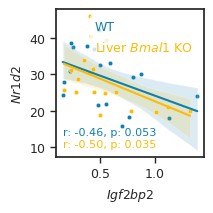

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

sns.set_theme(style="ticks")

colors = {
    "WT": "#0E7FAF",
    "KO": "#fbbc05"
}

# r/p annotation position
rpx = 0.05
rpy = 0.15
line_spacing = 0.08

fig, ax = plt.subplots(figsize=(2.3,2.3))

results = {}

for group, cols in {"WT": wt_cols, "KO": ko_cols}.items():

    x = df.loc["IGF2BP2", cols].astype(float)
    y = df.loc["NR1D2", cols].astype(float)

    # correlation
    r, p = pearsonr(x, y)

    results[group] = {"n": len(cols), "r": r, "p": p}

    # scatter
    sns.scatterplot(
        x=x,
        y=y,
        color=colors[group],
        s=10,
        legend=False,
        ax=ax
    )

    # regression line
    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        line_kws={"color":colors[group], "linewidth":1.5},
        ax=ax
    )

# axis labels
ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=9)

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["WT"],lw=0,label="WT"),
    Line2D([0],[0],color=colors["KO"],lw=0,label="Liver $\it{Bmal1}$ KO")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=9,loc="upper right"
)

for text, genotype in zip(legend.get_texts(), ["WT","KO"]):
    text.set_color(colors[genotype])

# r / p annotation
for i, group in enumerate(["WT","KO"]):

    r = results[group]["r"]
    p = results[group]["p"]

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        transform=ax.transAxes,
        color=colors[group],
        fontsize=8
    )

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE308276_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE308276_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE308276_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)



plt.show()

## GSE107787

In [43]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE107787/GSE107787_RNAseq_expression_results.xlsx"

df = pd.read_excel(
    file_path,
    engine='openpyxl',
    index_col= False
)
print(df)


          Gene  Muscle_FED_ZT00_Rep3  Muscle_FED_ZT00_Rep4  \
0         Xkr4               0.01147               0.01125   
1          Rp1               0.04275               0.06528   
2        Sox17               1.72219               1.37552   
3       Mrpl15              11.43258              13.26742   
4       Lypla1              38.52326              34.19680   
...        ...                   ...                   ...   
20556  Tspy-ps               0.00000               0.00000   
20557      Uty               3.19209               2.93277   
20558    Ddx3y              19.07917              14.62181   
20559    Usp9y               0.00000               0.00000   
20560    Erdr1               6.41690               2.92718   

       Muscle_FED_ZT00_Rep5  Muscle_FED_ZT04_Rep1  Muscle_FED_ZT04_Rep3  \
0                   0.00000               0.01147               0.01210   
1                   0.06363               0.01710               0.02255   
2                   1.89178   

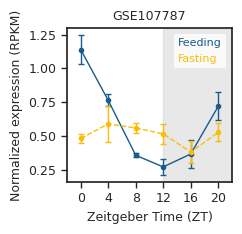

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# ----------------------------
# 2️⃣ Extract gene
# ----------------------------
gene_symbol = "IGF2BP2"

df["Gene"] = df["Gene"].astype(str).str.strip().str.upper()
gene_row = df[df["Gene"] == gene_symbol]

if gene_row.empty:
    raise ValueError("Gene not found.")

# ----------------------------
# 3️⃣ Extract Muscle columns
# ----------------------------
muscle_cols = [c for c in df.columns if c.startswith("Muscle_")]

groups = {
    "Muscle_FED": [],
    "Muscle_FAST": []
}

for col in muscle_cols:
    if "FED" in col:
        groups["Muscle_FED"].append(col)
    elif "FAST" in col:
        groups["Muscle_FAST"].append(col)

# ----------------------------
# 4️⃣ Build dataframe
# ----------------------------
data = []

for group, cols in groups.items():
    for col in cols:

        match = re.search(r"ZT(\d+)", col)
        if not match:
            continue

        time = int(match.group(1))
        value = float(gene_row[col].values[0])

        data.append((group, time, value))

data = pd.DataFrame(data, columns=["group","ZT","value"])

# ----------------------------
# 5️⃣ Mean ± SEM
# ----------------------------
summary = (
    data
    .groupby(["group","ZT"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# ----------------------------
# 6️⃣ Plot
# ----------------------------
colors = {
    "Muscle_FED": "#185b8c",
    "Muscle_FAST": "#fbbc05"
}

rhythmic_status = {
    "Muscle_FED": "rhythmic",
    "Muscle_FAST": "arrhythmic"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12,24,color="lightgray",alpha=0.5)

for group in ["Muscle_FED","Muscle_FAST"]:

    sub = summary[summary["group"] == group].sort_values("ZT")

    linestyle = "--" if rhythmic_status[group] == "arrhythmic" else "-"
    
    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[group],
        linestyle=linestyle
    )

plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel(r"Normalized expression (RPKM)", fontsize=9)

plt.xticks([0,4,8,12,16,20,24], fontsize=9)
plt.xlim(-2,22)

plt.yticks(fontsize=9)

plt.tick_params(direction="out", length=4, width=1)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["Muscle_FED"],lw=0,label="Feeding"),
    Line2D([0],[0],color=colors["Muscle_FAST"],lw=0,label="Fasting")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), ["Muscle_FED","Muscle_FAST"]):
    text.set_color(colors[g])

plt.title("GSE107787",fontsize=9)
plt.tight_layout()


# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE107787_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE107787_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE107787_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)



plt.show()

In [365]:
###correlation

In [84]:
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE107787/GSE107787_RNAseq_expression_results.xlsx"

df = pd.read_excel(file_path)

print(df.shape)
# Keep only first 36 columns
df = df.iloc[:, :37]

print("New shape:", df.shape)

# Check structure
print(df.head())
print(df.columns)

(20561, 73)
New shape: (20561, 37)
     Gene  Muscle_FED_ZT00_Rep3  Muscle_FED_ZT00_Rep4  Muscle_FED_ZT00_Rep5  \
0    Xkr4               0.01147               0.01125               0.00000   
1     Rp1               0.04275               0.06528               0.06363   
2   Sox17               1.72219               1.37552               1.89178   
3  Mrpl15              11.43258              13.26742              12.50647   
4  Lypla1              38.52326              34.19680              43.05566   

   Muscle_FED_ZT04_Rep1  Muscle_FED_ZT04_Rep3  Muscle_FED_ZT04_Rep5  \
0               0.01147               0.01210               0.01199   
1               0.01710               0.02255               0.04458   
2               1.40962               1.17231               1.00325   
3              16.05910              12.84987              13.68800   
4              41.50928              33.78573              27.47940   

   Muscle_FED_ZT08_Rep2  Muscle_FED_ZT08_Rep3  Muscle_FED_ZT08_

In [85]:
df["Gene"] = df["Gene"].str.strip().str.upper()
df = df.set_index("Gene")


In [86]:
print(df.head())
print(df.columns)
print("New shape:", df.shape)

        Muscle_FED_ZT00_Rep3  Muscle_FED_ZT00_Rep4  Muscle_FED_ZT00_Rep5  \
Gene                                                                       
XKR4                 0.01147               0.01125               0.00000   
RP1                  0.04275               0.06528               0.06363   
SOX17                1.72219               1.37552               1.89178   
MRPL15              11.43258              13.26742              12.50647   
LYPLA1              38.52326              34.19680              43.05566   

        Muscle_FED_ZT04_Rep1  Muscle_FED_ZT04_Rep3  Muscle_FED_ZT04_Rep5  \
Gene                                                                       
XKR4                 0.01147               0.01210               0.01199   
RP1                  0.01710               0.02255               0.04458   
SOX17                1.40962               1.17231               1.00325   
MRPL15              16.05910              12.84987              13.68800   
LYPLA1     

In [87]:
igf2bp2 = df.loc["IGF2BP2"]
nr1d2 = df.loc["NR1D2"]

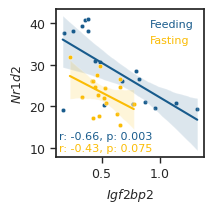

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

sns.set_theme(style="ticks")

groups = {
    "Fed": [c for c in df.columns if "FED" in str(c)],
    "Fast": [c for c in df.columns if "FAST" in str(c)]
}

colors = {
    "Fed": "#185b8c",
    "Fast": "#fbbc05"
}

results = {}

fig, ax = plt.subplots(figsize=(2.3,2.3))

# r/p text position
rpx = 0.02
rpy = 0.12
line_spacing = 0.08

for group, cols in groups.items():

    if len(cols) < 2:
        print(f"{group}: Not enough samples ({len(cols)})")
        continue

    x = igf2bp2[cols].astype(float)
    y = nr1d2[cols].astype(float)

    r, p = pearsonr(x, y)

    results[group] = {"n": len(cols), "r": r, "p": p}

    # scatter
    sns.scatterplot(
        x=x,
        y=y,
        color=colors[group],
        s=10,
        legend=False,
        ax=ax
    )

    # regression
    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        line_kws={"color":colors[group], "linewidth":1.5},
        ax=ax
    )

# axis labels
ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=9)

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["Fed"],lw=0,label="Feeding"),
    Line2D([0],[0],color=colors["Fast"],lw=0,label="Fasting")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8,loc="upper right"
)

for text, g in zip(legend.get_texts(), ["Fed","Fast"]):
    text.set_color(colors[g])

# r/p annotation
for i, g in enumerate(results):

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {results[g]['r']:.2f}, p: {results[g]['p']:.3f}",
        transform=ax.transAxes,
        color=colors[g],
        fontsize=8
    )

plt.tight_layout()



# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE107787_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE107787_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE107787_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)



plt.show()

## GSE195724

In [186]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE195724_RNAseq_gene_expression_log2FPKM.txt"
df = pd.read_csv(file_path, sep="\t")

print(df)

print(df.columns)

                       ID  WT_10w_ALF_1.ZT0  WT_10w_ALF_2.ZT0  \
0      ENSMUSG00000000001           2.80308           2.38744   
1      ENSMUSG00000000028          -0.30314           0.23868   
2      ENSMUSG00000000031           7.55013           8.26851   
3      ENSMUSG00000000049          -0.67754          -0.51468   
4      ENSMUSG00000000056           4.30070           4.99898   
...                   ...               ...               ...   
14408  ENSMUSG00000107355          -0.81078          -0.53935   
14409  ENSMUSG00000107368          -3.08195          -6.12728   
14410  ENSMUSG00000107369           0.74520           0.06490   
14411  ENSMUSG00000107374          -0.75542          -1.22121   
14412  ENSMUSG00000107383           4.22018           2.69050   

       WT_10w_ALF_4.ZT0  WT_10w_ALF_5.ZT4  WT_10w_ALF_6.ZT4  WT_10w_ALF_7.ZT4  \
0               2.29631           2.33197           2.22694           2.16788   
1               0.31724           0.50436           0.259

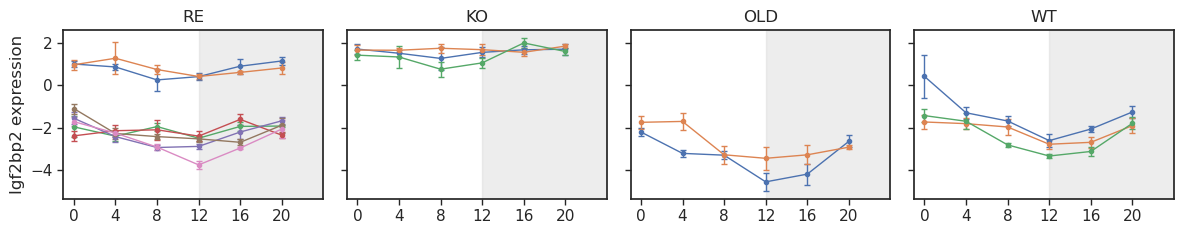

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd

sns.set_theme(style="ticks")

gene_id = "ENSMUSG00000033581"
gene_row = df[df["ID"] == gene_id].iloc[0]

records = []

pattern = re.compile(r"(.*)\.(ZT\d+)")

for col in df.columns[1:]:

    match = pattern.search(col)
    if not match:
        continue

    cond = col.split("_")[0:3]
    cond = "_".join(cond)

    zt = int(match.group(2).replace("ZT",""))
    value = float(gene_row[col])

    records.append((cond, zt, value))

data = pd.DataFrame(records, columns=["condition","ZT","expression"])

# -------------------------
# Define genotype groups
# -------------------------

group_map = {
    "WT":"WT",
    "KO":"KO",
    "RE":"RE",
    "Mu":"RE",
    "Br":"RE",
    "Old":"OLD",
    "DRF":"FEED",
    "NRF":"FEED",
    "Feeding":"FEED",
}

def assign_group(cond):

    for k,v in group_map.items():
        if k in cond:
            return v
    return "OTHER"

data["group"] = data["condition"].apply(assign_group)

# -------------------------
# Mean ± SEM
# -------------------------

summary = (
    data.groupby(["condition","group","ZT"])
    .agg(mean=("expression","mean"),
         sem=("expression","sem"))
    .reset_index()
)

# -------------------------
# Plot panels
# -------------------------

groups = summary["group"].unique()

fig, axes = plt.subplots(1, len(groups), figsize=(3*len(groups),2.5), sharey=True)

for ax, g in zip(axes, groups):

    sub = summary[summary["group"] == g]

    for cond in sub["condition"].unique():

        d = sub[sub["condition"] == cond].sort_values("ZT")

        ax.errorbar(
            d["ZT"],
            d["mean"],
            yerr=d["sem"],
            marker='o',
            markersize=3,
            linewidth=1,
            capsize=2,
            label=cond
        )

    ax.axvspan(12,24,color="lightgray",alpha=0.4)
    ax.set_title(g)
    ax.set_xlim(-1,24)
    ax.set_xticks([0,4,8,12,16,20])
    ax.tick_params(direction="out", length=4, width=1)

axes[0].set_ylabel("Igf2bp2 expression")

plt.tight_layout()
plt.show()

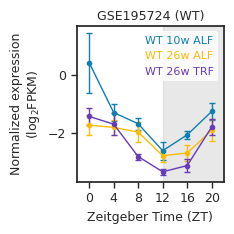

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# Gene
# -------------------------
gene_id = "ENSMUSG00000033581"  # ENSMUSG00000021775
gene_row = df[df["ID"] == gene_id].iloc[0]

# -------------------------
# Select conditions
# -------------------------
groups = {
    "WT_10w_ALF": [c for c in df.columns if "WT_10w_ALF" in c],
    "WT_26w_ALF": [c for c in df.columns if "WT_26w_ALF" in c],
    "WT_26w_TRF": [c for c in df.columns if "WT_26w_TRF" in c]
}

# rhythmicity
rhythmic_status = {
    "WT_10w_ALF": "rhythmic",
    "WT_26w_ALF": "rhythmic",
    "WT_26w_TRF": "rhythmic"
}

# -------------------------
# Build dataframe
# -------------------------
records = []

for group, cols in groups.items():
    for col in cols:

        match = re.search(r"ZT(\d+)", col)
        if not match:
            continue

        zt = int(match.group(1))
        val = float(gene_row[col])

        records.append((group, zt, val))

data = pd.DataFrame(records, columns=["group","ZT","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["group","ZT"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Plot
# -------------------------
colors = {
    "WT_10w_ALF": "#0E7FAF",
    "WT_26w_ALF": "#fbbc05",
    "WT_26w_TRF": "#673ab7"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12,24,color="lightgrey",alpha=0.5)

for g in groups:

    sub = summary[summary["group"] == g].sort_values("ZT")

    linestyle = "--" if rhythmic_status[g] == "arrhythmic" else "-"

    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[g],
        linestyle=linestyle
    )

# axis
plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized expression\n(log$_2$FPKM)", fontsize=9)

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2,22)

plt.yticks(fontsize=9)

plt.tick_params(direction="out", length=4, width=1)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["WT_10w_ALF"],lw=0,label="WT 10w ALF"),
    Line2D([0],[0],color=colors["WT_26w_ALF"],lw=0,label="WT 26w ALF"),
    Line2D([0],[0],color=colors["WT_26w_TRF"],lw=0,label="WT 26w TRF")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

plt.title("GSE195724 (WT)", fontsize=9, pad=4)

plt.tight_layout()

# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724WT_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724WT_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724WT_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)

plt.show()

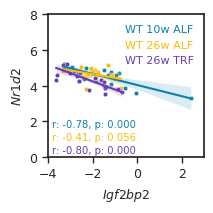

In [189]:
## wt correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# genes
# -------------------------
igf = df[df["ID"]=="ENSMUSG00000033581"].iloc[0]
nr1d2 = df[df["ID"]=="ENSMUSG00000021775"].iloc[0]

# -------------------------
# groups
# -------------------------
groups = {
    "WT_10w_ALF": [c for c in df.columns if "WT_10w_ALF" in c],
    "WT_26w_ALF": [c for c in df.columns if "WT_26w_ALF" in c],
    "WT_26w_TRF": [c for c in df.columns if "WT_26w_TRF" in c]
}

colors = {
    "WT_10w_ALF": "#0E7FAF",
    "WT_26w_ALF": "#fbbc05",
    "WT_26w_TRF": "#673ab7"
}

# text position (edit if needed)
rpx = -3.8
rpy = 1.7
line_spacing = 0.75

fig, ax = plt.subplots(figsize=(2.3,2.3))

# -------------------------
# scatter + regression
# -------------------------
for g, cols in groups.items():

    x = igf[cols].astype(float)
    y = nr1d2[cols].astype(float)

    sns.scatterplot(
        x=x,
        y=y,
        color=colors[g],
        s=10,
        legend=False,
        ax=ax
    )

    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        line_kws={"color":colors[g],"linewidth":1.5},
        ax=ax
    )

# -------------------------
# axis styling
# -------------------------
ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=9)
plt.ylim(0,8)
plt.xlim(-4,3)
ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# -------------------------
# legend
# -------------------------
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g.replace("_"," "))
    for g in groups
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

# -------------------------
# r and p values
# -------------------------
for i,(g,cols) in enumerate(groups.items()):

    x = igf[cols].astype(float)
    y = nr1d2[cols].astype(float)

    r,p = pearsonr(x,y)

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[g],
        fontsize=7.2
    )

# plt.title("GSE195724 (WT)", fontsize=9)

plt.tight_layout()



# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724WT_igf2bp2_nr1d2_corr.tiff",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724WT_igf2bp2_nr1d2_corr.png",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724WT_igf2bp2_nr1d2_corr.svg",
#             bbox_inches="tight", transparent=True)



plt.show()

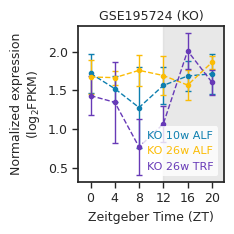

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# Gene
# -------------------------
gene_id = "ENSMUSG00000033581"  # ENSMUSG00000021775
gene_row = df[df["ID"] == gene_id].iloc[0]

# -------------------------
# Select conditions
# -------------------------
groups = {
    "KO_10w_ALF": [c for c in df.columns if "KO_10w_ALF" in c],
    "KO_26w_ALF": [c for c in df.columns if "KO_26w_ALF" in c],
    "KO_26w_TRF": [c for c in df.columns if "KO_26w_TRF" in c]
}

# rhythmicity
rhythmic_status = {
    "KO_10w_ALF": "arrhythmic",
    "KO_26w_ALF": "arrhythmic",
    "KO_26w_TRF": "arrhythmic"
}

# -------------------------
# Build dataframe
# -------------------------
records = []

for group, cols in groups.items():
    for col in cols:

        match = re.search(r"ZT(\d+)", col)
        if not match:
            continue

        zt = int(match.group(1))
        val = float(gene_row[col])

        records.append((group, zt, val))

data = pd.DataFrame(records, columns=["group","ZT","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["group","ZT"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Plot
# -------------------------
colors = {
    "KO_10w_ALF": "#0E7FAF",
    "KO_26w_ALF": "#fbbc05",
    "KO_26w_TRF": "#673ab7"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12,24,color="lightgrey",alpha=0.5)

for g in groups:

    sub = summary[summary["group"] == g].sort_values("ZT")

    linestyle = "--" if rhythmic_status[g] == "arrhythmic" else "-"

    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[g],
        linestyle=linestyle
    )

plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized expression\n(log$_2$FPKM)", fontsize=9)

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2,22)

plt.yticks(fontsize=9)

plt.tick_params(direction="out", length=4, width=1)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["KO_10w_ALF"],lw=0,label="KO 10w ALF"),
    Line2D([0],[0],color=colors["KO_26w_ALF"],lw=0,label="KO 26w ALF"),
    Line2D([0],[0],color=colors["KO_26w_TRF"],lw=0,label="KO 26w TRF")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

plt.title("GSE195724 (KO)", fontsize=9, pad=4)

plt.tight_layout()

# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724KO_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724KO_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724KO_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)

plt.show()

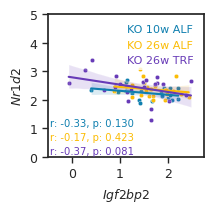

In [191]:
##  ko correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# genes
# -------------------------
igf = df[df["ID"]=="ENSMUSG00000033581"].iloc[0]
nr1d2 = df[df["ID"]=="ENSMUSG00000021775"].iloc[0]

# -------------------------
# groups
# -------------------------
groups = {
    "KO_10w_ALF": [c for c in df.columns if "KO_10w_ALF" in c],
    "KO_26w_ALF": [c for c in df.columns if "KO_26w_ALF" in c],
    "KO_26w_TRF": [c for c in df.columns if "KO_26w_TRF" in c]
}

colors = {
    "KO_10w_ALF": "#0E7FAF",
    "KO_26w_ALF": "#fbbc05",
    "KO_26w_TRF": "#673ab7"
}

# position for r/p text
rpx = -0.45
rpy = 1.1
line_spacing = 0.5

fig, ax = plt.subplots(figsize=(2.3,2.3))

# -------------------------
# scatter + regression
# -------------------------
for g, cols in groups.items():

    x = igf[cols].astype(float)
    y = nr1d2[cols].astype(float)

    sns.scatterplot(
        x=x,
        y=y,
        color=colors[g],
        s=10,
        legend=False,
        ax=ax
    )

    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        line_kws={"color":colors[g],"linewidth":1.5},
        ax=ax
    )

# -------------------------
# axis style
# -------------------------
ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=9)

plt.xlim(-0.5,2.75)
plt.ylim(0,5)

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# -------------------------
# legend (colored text)
# -------------------------
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g.replace("_"," "))
    for g in groups
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8,
    loc="upper right"
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

# -------------------------
# r / p annotation
# -------------------------
for i,(g,cols) in enumerate(groups.items()):

    x = igf[cols].astype(float)
    y = nr1d2[cols].astype(float)

    r,p = pearsonr(x,y)

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[g],
        fontsize=7.2
    )

# plt.title("GSE195724 (KO)", fontsize=9)

plt.tight_layout()


# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724KO_igf2bp2_nr1d2_corr.tiff",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724KO_igf2bp2_nr1d2_corr.png",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724KO_igf2bp2_nr1d2_corr.svg",
#             bbox_inches="tight", transparent=True)


plt.show()

MuRE_10w_ALF 25
MuRE_26w_ALF 24
MuRE_26w_TRF 23
BrRE_10w_ALF 23
BrRE_26w_ALF 22
RE_10w_ALF 24
RE_26w_ALF 24


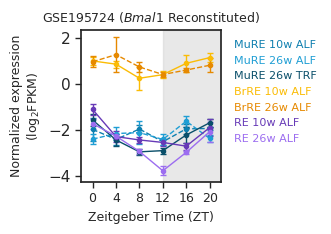

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# Gene
# -------------------------
gene_id = "ENSMUSG00000033581"
gene_row = df[df["ID"] == gene_id].iloc[0]

# -------------------------
# Select conditions
# -------------------------
groups = {
    "MuRE_10w_ALF": [c for c in df.columns if "Mu-RE_10w_ALF" in c],
    "MuRE_26w_ALF": [c for c in df.columns if "Mu-RE_26w_ALF" in c],
    "MuRE_26w_TRF": [c for c in df.columns if "Mu-RE_26w_TRF" in c],

    "BrRE_10w_ALF": [c for c in df.columns if "Br-RE_10w_ALF" in c],
    "BrRE_26w_ALF": [c for c in df.columns if "Br-RE_26w_ALF" in c],

    "RE_10w_ALF": [c for c in df.columns if "RE-RE_10w_ALF" in c],
    "RE_26w_ALF": [c for c in df.columns if "RE-RE_26w_ALF" in c]
}

for g in groups:
    print(g, len(groups[g]))

# -------------------------
# Rhythmicity (from heatmap)
# -------------------------
rhythmic_status = {
    "MuRE_10w_ALF": "arrhythmic",
    "MuRE_26w_ALF": "arrhythmic",
    "MuRE_26w_TRF": "rhythmic",

    "BrRE_10w_ALF": "rhythmic",
    "BrRE_26w_ALF": "arrhythmic",

    "RE_10w_ALF": "rhythmic",
    "RE_26w_ALF": "rhythmic"
}

# -------------------------
# Build dataframe
# -------------------------
records = []

for group, cols in groups.items():
    for col in cols:

        match = re.search(r"ZT(\d+)", col)
        if not match:
            continue

        zt = int(match.group(1))
        val = float(gene_row[col])

        records.append((group, zt, val))

data = pd.DataFrame(records, columns=["group","ZT","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["group","ZT"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Colors (unique for each)
# -------------------------
colors = {
    "MuRE_10w_ALF": "#0E7FAF",
    "MuRE_26w_ALF": "#1f9ed4",
    "MuRE_26w_TRF": "#0a4f6a",

    "BrRE_10w_ALF": "#fbbc05",
    "BrRE_26w_ALF": "#e68900",

    "RE_10w_ALF": "#673ab7",
    "RE_26w_ALF": "#9c6df0"
}

plt.figure(figsize=(3.5,2.5))

plt.axvspan(12,24,color="lightgrey",alpha=0.5)

legend_elements = []

for g in groups:

    sub = summary[summary["group"] == g].sort_values("ZT")

    linestyle = "--" if rhythmic_status[g] == "arrhythmic" else "-"

    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[g],
        linestyle=linestyle
    )

    legend_elements.append(
        Line2D([0],[0],color=colors[g],lw=2,label=g.replace("_"," "))
    )

plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized expression\n(log$_2$FPKM)", fontsize=9)

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2,22)

plt.tick_params(direction="out", length=4, width=1)

# -------------------------
# Legend outside (colored text, no line)
# -------------------------
legend_elements = [
    Line2D([0],[0], color=colors[g], lw=0, label=g.replace("_"," "))
    for g in groups
]

legend = plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

# color legend text
for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])
    
plt.title("GSE195724 ($\it{Bmal1}$ Reconstituted)", fontsize=9)

plt.tight_layout()


# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724RE_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724RE_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724RE_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)


plt.show()

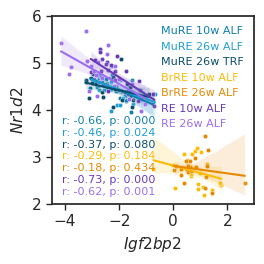

In [193]:
##reconstituted correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# genes
# -------------------------
igf = df[df["ID"]=="ENSMUSG00000033581"].iloc[0]
nr1d2 = df[df["ID"]=="ENSMUSG00000021775"].iloc[0]

# -------------------------
# groups
# -------------------------
groups = {
    "MuRE_10w_ALF": [c for c in df.columns if "Mu-RE_10w_ALF" in c],
    "MuRE_26w_ALF": [c for c in df.columns if "Mu-RE_26w_ALF" in c],
    "MuRE_26w_TRF": [c for c in df.columns if "Mu-RE_26w_TRF" in c],

    "BrRE_10w_ALF": [c for c in df.columns if "Br-RE_10w_ALF" in c],
    "BrRE_26w_ALF": [c for c in df.columns if "Br-RE_26w_ALF" in c],

    "RE_10w_ALF": [c for c in df.columns if "RE-RE_10w_ALF" in c],
    "RE_26w_ALF": [c for c in df.columns if "RE-RE_26w_ALF" in c]
}

# -------------------------
# colors (same as plot)
# -------------------------
colors = {
    "MuRE_10w_ALF": "#0E7FAF",
    "MuRE_26w_ALF": "#1f9ed4",
    "MuRE_26w_TRF": "#0a4f6a",

    "BrRE_10w_ALF": "#fbbc05",
    "BrRE_26w_ALF": "#e68900",

    "RE_10w_ALF": "#673ab7",
    "RE_26w_ALF": "#9c6df0"
}

# text position
rpx = -4.1
rpy = 3.7
line_spacing = 0.25

fig, ax = plt.subplots(figsize=(2.8,2.8))

# -------------------------
# scatter + regression
# -------------------------
for g, cols in groups.items():

    x = igf[cols].astype(float)
    y = nr1d2[cols].astype(float)

    sns.scatterplot(
        x=x,
        y=y,
        color=colors[g],
        s=10,
        legend=False,
        ax=ax
    )

    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        line_kws={"color":colors[g],"linewidth":1.5},
        ax=ax
    )

# -------------------------
# axis styling
# -------------------------
ax.set_xlabel(r"$\it{Igf2bp2}$", fontsize=11)
ax.set_ylabel(r"$\it{Nr1d2}$", fontsize=11)

ax.tick_params(direction="out", length=4, width=1, labelsize=11)

plt.ylim(2,6)
plt.yticks(np.arange(2, 7, 1))
# -------------------------
# legend (colored text)
# -------------------------
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g.replace("_"," "))
    for g in groups
]

legend = ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1,1),
    loc="upper right",
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

# -------------------------
# r / p values
# -------------------------
for i,(g,cols) in enumerate(groups.items()):

    x = igf[cols].astype(float)
    y = nr1d2[cols].astype(float)

    r,p = pearsonr(x,y)

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[g],
        fontsize=8
    )

# plt.title("GSE195724 ($\it{Bmal1}$ Reconstituted)", fontsize=9)

plt.tight_layout()


# # save figure
# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724RE_igf2bp2_nr1d2_corr.tiff",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724RE_igf2bp2_nr1d2_corr.png",
#             dpi=300, bbox_inches="tight", transparent=True)

# plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724RE_igf2bp2_nr1d2_corr.svg",
#             bbox_inches="tight", transparent=True)




plt.show()

In [194]:
print([c for c in df.columns if "Old" in c][:353])

['Old_96w_ALF_1.ZT0', 'Old_96w_ALF_2.ZT0', 'Old_96w_ALF_3.ZT0', 'Old_96w_ALF_4.ZT0', 'Old_96w_ALF_5.ZT4', 'Old_96w_ALF_6.ZT4', 'Old_96w_ALF_7.ZT4', 'Old_96w_ALF_8.ZT4', 'Old_96w_ALF_9.ZT8', 'Old_96w_ALF_10.ZT8', 'Old_96w_ALF_11.ZT8', 'Old_96w_ALF_12.ZT8', 'Old_96w_ALF_13.ZT12', 'Old_96w_ALF_14.ZT12', 'Old_96w_ALF_15.ZT12', 'Old_96w_ALF_16.ZT12', 'Old_96w_ALF_17.ZT16', 'Old_96w_ALF_18.ZT16', 'Old_96w_ALF_19.ZT16', 'Old_96w_ALF_20.ZT16', 'Old_96w_ALF_21.ZT20', 'Old_96w_ALF_22.ZT20', 'Old_96w_ALF_23.ZT20', 'Old_96w_ALF_24.ZT20', 'Old_96w_TRF_1.ZT0', 'Old_96w_TRF_2.ZT0', 'Old_96w_TRF_3.ZT0', 'Old_96w_TRF_4.ZT0', 'Old_96w_TRF_5.ZT4', 'Old_96w_TRF_6.ZT4', 'Old_96w_TRF_7.ZT4', 'Old_96w_TRF_8.ZT4', 'Old_96w_TRF_9.ZT8', 'Old_96w_TRF_10.ZT8', 'Old_96w_TRF_11.ZT8', 'Old_96w_TRF_12.ZT8', 'Old_96w_TRF_13.ZT12', 'Old_96w_TRF_14.ZT12', 'Old_96w_TRF_15.ZT12', 'Old_96w_TRF_16.ZT12', 'Old_96w_TRF_17.ZT16', 'Old_96w_TRF_18.ZT16', 'Old_96w_TRF_19.ZT16', 'Old_96w_TRF_20.ZT16', 'Old_96w_TRF_21.ZT20', 'Old_9

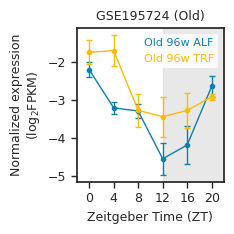

In [195]:
# -------------------------
# Select conditions
# -------------------------
groups = {
    "Old_96w_ALF": [c for c in df.columns if "Old_96w_ALF" in c],
    "Old_96w_TRF": [c for c in df.columns if "Old_96w_TRF" in c]
}

# rhythmicity
rhythmic_status = {
    "Old_96w_ALF": "rhythmic",
    "Old_96w_TRF": "rhythmic"
}

# -------------------------
# Build dataframe
# -------------------------
records = []

for group, cols in groups.items():
    for col in cols:

        match = re.search(r"ZT(\d+)", col)
        if not match:
            continue

        zt = int(match.group(1))
        val = float(gene_row[col])

        records.append((group, zt, val))

data = pd.DataFrame(records, columns=["group","ZT","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["group","ZT"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Plot
# -------------------------
colors = {
    "Old_96w_ALF": "#0E7FAF",
    "Old_96w_TRF": "#fbbc05"
}

plt.figure(figsize=(2.5,2.5))

plt.axvspan(12,24,color="lightgrey",alpha=0.5)

for g in groups:

    sub = summary[summary["group"] == g].sort_values("ZT")

    linestyle = "--" if rhythmic_status[g] == "arrhythmic" else "-"

    plt.errorbar(
        sub["ZT"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[g],
        linestyle=linestyle
    )

plt.xlabel("Zeitgeber Time (ZT)", fontsize=9)
plt.ylabel("Normalized expression\n(log$_2$FPKM)", fontsize=9)

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2,22)

plt.yticks(fontsize=9)

plt.tick_params(direction="out", length=4, width=1)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["Old_96w_ALF"],lw=0,label="Old 96w ALF"),
    Line2D([0],[0],color=colors["Old_96w_TRF"],lw=0,label="Old 96w TRF")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

plt.title("GSE195724 (Old)", fontsize=9)

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724Old_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724Old_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724Old_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)


plt.show()

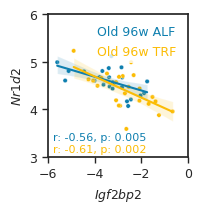

In [196]:
##old correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

# -------------------------
# Extract genes
# -------------------------
igf = df[df["ID"]=="ENSMUSG00000033581"].iloc[0]
nr1d2 = df[df["ID"]=="ENSMUSG00000021775"].iloc[0]

# -------------------------
# Select groups
# -------------------------
groups = {
    "Old_96w_ALF": [c for c in df.columns if "Old_96w_ALF" in c],
    "Old_96w_TRF": [c for c in df.columns if "Old_96w_TRF" in c]
}

# -------------------------
# Build corr_df
# -------------------------
records = []

for g, cols in groups.items():
    for col in cols:
        records.append({
            "Igf2bp2": float(igf[col]),
            "Nr1d2": float(nr1d2[col]),
            "Genotype": g
        })

corr_df = pd.DataFrame(records)

# -------------------------
# Colors
# -------------------------
colors = {
    "Old_96w_ALF": "#0E7FAF",
    "Old_96w_TRF": "#fbbc05"
}

# r/p annotation position
rpx = -5.8
rpy = 3.35
line_spacing = 0.25

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(2.3,2.3))

sns.scatterplot(
    data=corr_df,
    x="Igf2bp2",
    y="Nr1d2",
    hue="Genotype",
    palette=colors,
    s=10,
    legend=False,
    ax=ax
)

# regression lines
for g in groups:

    sub = corr_df[corr_df["Genotype"] == g]

    sns.regplot(
        data=sub,
        x="Igf2bp2",
        y="Nr1d2",
        scatter=False,
        line_kws={"color":colors[g],"linewidth":1.5},
        ax=ax
    )

# axis
ax.set_xlabel(r"$\it{Igf2bp2}$",fontsize=9)
ax.set_ylabel(r"$\it{Nr1d2}$",fontsize=9)

plt.ylim(3,6)
plt.xlim(-6,0)
ax.tick_params(direction="out", length=4, width=1,labelsize=9)

# legend
legend_elements = [
    Line2D([0],[0],color=colors["Old_96w_ALF"],lw=0,label="Old 96w ALF"),
    Line2D([0],[0],color=colors["Old_96w_TRF"],lw=0,label="Old 96w TRF")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=9,
    loc="upper right"
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

# r / p values
for i, g in enumerate(groups):

    sub = corr_df[corr_df["Genotype"] == g]
    r,p = pearsonr(sub["Igf2bp2"], sub["Nr1d2"])

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[g],
        fontsize=8
    )

# plt.title("GSE195724 (Old)", fontsize=9)

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724OLD_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724OLD_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE195724OLD_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)

plt.show()

## Human data

## GSE182117

In [197]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE182117/GSE182117_logCPM_batchCorrected.tsv"
df = pd.read_csv(file_path, sep="\t")


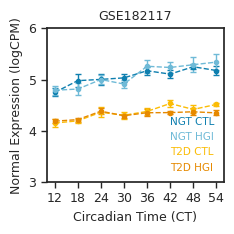

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# Extract gene
# -------------------------
gene_id = "ENSG00000073792" # ENSG00000174738  , ENSG00000073792

df["Gene_clean"] = df["Tags"].str.split(".").str[0]
gene_row = df[df["Gene_clean"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# Organize replicate-level data
# -------------------------
records = []
pattern = re.compile(r"(NGT|T2D)_(CTL|HGI)_(\d+)h_i\d+")

for col in df.columns:
    match = pattern.match(col)
    if match:

        group = f"{match.group(1)}_{match.group(2)}"
        time = int(match.group(3))

        value = float(gene_row[col].values[0])

        records.append((group, time, value))

data = pd.DataFrame(records, columns=["group","time","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["group","time"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Colors
# -------------------------
colors = {
    "NGT_CTL": "#0E7FAF",   # base NGT
    "NGT_HGI": "#6FBAD7",   # lighter NGT

    "T2D_CTL": "#fbbc05",   # base T2D
    "T2D_HGI": "#e68900"    # lighter T2D
}
# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(2.5,2.5))

for g in sorted(summary["group"].unique()):

    sub = summary[summary["group"] == g].sort_values("time")

    plt.errorbar(
        sub["time"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[g],
        linestyle="--"   # dashed since arrhythmic
    )

# -------------------------
# Styling
# -------------------------
plt.xlabel("Circadian Time (CT)", fontsize=9)
plt.ylabel("Normal Expression (logCPM)", fontsize=9)

plt.xticks(np.arange(0,61,6), fontsize=9)
plt.xlim(10,56)
plt.ylim(3,6)
plt.yticks(np.arange(3,7,1), fontsize=9)

plt.tick_params(direction="out", length=4, width=1)

# -------------------------
# Legend (colored text)
# -------------------------
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g.replace("_"," "))
    for g in colors
]

legend = plt.legend(
    handles=legend_elements,
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=7.5
)

for text, g in zip(legend.get_texts(), colors.keys()):
    text.set_color(colors[g])
plt.title("GSE182117",fontsize =9)
plt.tight_layout()



# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE182117_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE182117_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE182117_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)


plt.show()

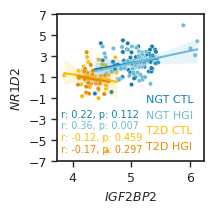

In [199]:
#correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

# -------------------------
# Extract genes
# -------------------------
igf = df[df["Gene_clean"]=="ENSG00000073792"].iloc[0]
nr1d2 = df[df["Gene_clean"]=="ENSG00000126368"].iloc[0]   # NR1D2

# -------------------------
# Select groups
# -------------------------
groups = {
    "NGT_CTL": [c for c in df.columns if "NGT_CTL" in c],
    "NGT_HGI": [c for c in df.columns if "NGT_HGI" in c],
    "T2D_CTL": [c for c in df.columns if "T2D_CTL" in c],
    "T2D_HGI": [c for c in df.columns if "T2D_HGI" in c]
}

# -------------------------
# Build corr_df
# -------------------------
records = []

for g, cols in groups.items():
    for col in cols:
        records.append({
            "Igf2bp2": float(igf[col]),
            "Nr1d2": float(nr1d2[col]),
            "Genotype": g
        })

corr_df = pd.DataFrame(records)

# -------------------------
# Colors
# -------------------------
colors = {
    "NGT_CTL": "#0E7FAF",
    "NGT_HGI": "#6FBAD7",
    "T2D_CTL": "#fbbc05",
    "T2D_HGI": "#e68900"
}

# r/p annotation position (adjust if needed)
rpx = 3.8
rpy = -2.8
line_spacing = 1.1

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(2.3,2.3))

sns.scatterplot(
    data=corr_df,
    x="Igf2bp2",
    y="Nr1d2",
    hue="Genotype",
    palette=colors,
    s=10,
    legend=False,
    ax=ax
)

# regression lines
for g in groups:

    sub = corr_df[corr_df["Genotype"] == g]

    sns.regplot(
        data=sub,
        x="Igf2bp2",
        y="Nr1d2",
        scatter=False,
        line_kws={"color":colors[g],"linewidth":1.5},
        ax=ax
    )

# axis
ax.set_xlabel(r"$\it{IGF2BP2}$",fontsize=9)
ax.set_ylabel(r"$\it{NR1D2}$",fontsize=9)

ax.tick_params(direction="out", length=4, width=1,labelsize=9)

plt.ylim(-6,7)
plt.yticks(np.arange(-7,8,2), fontsize=9)

# legend
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g.replace("_"," "))
    for g in groups
]

legend = ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    handlelength=0,
    handletextpad=0,
    fontsize=8,
    loc="lower right"
)

for text, g in zip(legend.get_texts(), groups.keys()):
    text.set_color(colors[g])

# r / p values
for i, g in enumerate(groups):

    sub = corr_df[corr_df["Genotype"] == g]
    r,p = pearsonr(sub["Igf2bp2"], sub["Nr1d2"])

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[g],
        fontsize=7
    )

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE182117_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE182117_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE182117_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)


plt.show()

## GSE109825

In [200]:

# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE109825/GSE109825_invitro_rpkm_matrix_formated.txt"

df = pd.read_csv(
    file_path,
    sep="\t",
    index_col=False
)


In [201]:
# print row names top 5
print(df.index[:5])
print(df.columns[:5])

RangeIndex(start=0, stop=5, step=1)
Index(['#Ensembl_id', 'coordinates', 'gene_name', 'donor1_siClock_95_140505_2',
       'donor1_siCtrl_3_140505_2'],
      dtype='object')


In [ ]:
# # -------------------------
# # Extract gene
# # -------------------------
# gene_symbol = "IGF2BP2"

# df["gene_name"] = df["gene_name"].astype(str).str.strip().str.upper()
# gene_row = df[df["gene_name"] == gene_symbol]

# if gene_row.empty:
#     raise ValueError("Gene not found.")

# # -------------------------
# # Cosinor model
# # -------------------------
# def cosinor(t, M, A, phi):
#     return M + A * np.cos(2*np.pi/24 * (t - phi))

# # -------------------------
# # Time maps
# # -------------------------

# siCtrl_map = {
#     0: ["donor1_siCtrl1_140313_6", "donor2_siCtrl1_140313_8"],
#     2: ["donor1_siCtrl_3_140505_2", "donor2_siCtrl3_140313_4"],
#     4: ["donor1_siCtrl5_140313_6", "donor2_siCtrl5_140313_8"],
#     6: ["donor1_siCtrl7_140313_5", "donor2_siCtrl7_140313_3"],
#     8: ["donor1_siCtrl9_140313_5", "donor2_siCtrl9_140313_3"],
#     10:["donor1_siCtrl11_140313_7","donor2_siCtrl11_140313_1"],
#     12:["donor1_siCtrl13_140313_6","donor2_siCtrl13_140313_1"],
#     14:["donor1_siCtrl15_140313_5","donor2_siCtrl15_140313_2"],
#     16:["donor1_siCtrl17_140313_6","donor2_siCtrl17_140313_4"],
#     18:["donor1_siCtrl19_140313_8","donor2_siCtrl19_140313_6"],
#     20:["donor1_siCtrl21_140313_6","donor2_siCtrl_21_140505_1"],
#     22:["donor1_siCtrl23_140313_2","donor2_siCtrl23_140313_2"],
#     24:["donor1_siCtrl25_140313_6","donor2_siCtrl25_140313_2"],
#     26:["donor1_siCtrl27_140313_6","donor2_siCtrl27_140313_1"],
#     28:["donor1_siCtrl29_140313_5","donor2_siCtrl29_140313_3"],
#     30:["donor1_siCtrl31_140313_7","donor2_siCtrl31_140313_1"],
#     32:["donor1_siCtrl33_140313_8","donor2_siCtrl33_140313_4"],
#     34:["donor1_siCtrl35_140313_5","donor2_siCtrl35_140313_2"],
#     36:["donor1_siCtrl37_140313_5","donor2_siCtrl37_140313_3"],
#     38:["donor1_siCtrl39_140313_5","donor2_siCtrl39_140313_8"],
#     40:["donor1_siCtrl41_140313_5","donor2_siCtrl41_140313_4"],
#     42:["donor1_siCtrl43_140313_5","donor2_siCtrl43_140313_4"],
#     44:["donor1_siCtrl45_140313_7","donor2_siCtrl45_140313_1"],
#     46:["donor1_siCtrl47_140313_7","donor2_siCtrl47_140313_1"],
#     48:["donor1_siCtrl49_140313_6","donor2_siCtrl49_140313_3"],
# }

# siClock_map = {
#     0:["donor1_siClock51_140313_4","donor2_siClock51_140313_8"],
#     2:["donor1_siClock53_140313_7","donor2_siClock53_140313_1"],
#     4:["donor1_siClock55_140313_6","donor2_siClock55_140313_1"],
#     6:["donor1_siClock57_140313_1","donor2_siClock57_140313_2"],
#     8:["donor1_siClock59_140313_8","donor2_siClock59_140313_4"],
#     10:["donor1_siClock61_140313_8","donor2_siClock61_140313_7"],
#     12:["donor1_siClock63_140313_6","donor2_siClock63_140313_3"],
#     14:["donor1_siClock65_140313_6","donor2_siClock65_140313_2"],
#     16:["donor1_siClock67_140313_7","donor2_siClock67_140313_4"],
#     18:["donor1_siClock69_140313_7","donor2_siClock69_140313_1"],
#     20:["donor1_siClock71_140313_5","donor2_siClock71_140313_4"],
#     22:["donor1_siClock73_140313_5","donor2_siClock73_140313_1"],
#     24:["donor1_siClock75_140313_7","donor2_siClock75_140313_3"],
#     26:["donor1_siClock77_140313_3","donor2_siClock_77_140505_2"],
#     28:["donor1_siClock79_140313_7","donor2_siClock79_140313_4"],
#     30:["donor1_siClock81_140313_8","donor2_siClock81_140313_3"],
#     32:["donor1_siClock83_140313_3","donor2_siClock83_140313_2"],
#     34:["donor1_siClock85_140313_1","donor2_siClock85_140313_8"],
#     36:["donor1_siClock87_140313_8","donor2_siClock87_140313_2"],
#     38:["donor1_siClock89_140313_7","donor2_siClock89_140313_4"],
#     40:["donor1_siClock91_140313_5","donor2_siClock91_140313_4"],
#     42:["donor1_siClock93_140313_2","donor2_siClock93_140313_2"],
#     44:["donor1_siClock_95_140505_2","donor2_siClock95_140313_3"],
#     46:["donor1_siClock97_140313_8","donor2_siClock97_140313_2"],
#     48:["donor1_siClock99_140313_7","donor2_siClock99_140313_3"],
# }

# # -------------------------
# # Color control (EDIT HEX HERE)
# # -------------------------
# colors = {
#     "Donor1_siCtrl": "#185b8c",
#     "Donor2_siCtrl": "#73b7e7",
#     "Donor1_siClock": "#d16200",
#     "Donor2_siClock": "#ffa85c",
# }

# # -------------------------
# # Plot
# # -------------------------
# sns.set_style("white")
# plt.figure(figsize=(2.5,2.5))
# groups = [
#     ("Donor1_siCtrl", siCtrl_map, 0),
#     ("Donor2_siCtrl", siCtrl_map, 1),
#     ("Donor1_siClock", siClock_map, 0),
#     ("Donor2_siClock", siClock_map, 1),
# ]

# for label, mapping, donor_idx in groups:

#     times = []
#     values = []

#     for t, cols in mapping.items():
#         val = float(gene_row[cols[donor_idx]].values[0])
#         times.append(t)
#         values.append(np.log2(val + 1e-6))  # log2 RPKM

#     times = np.array(times)
#     values = np.array(values)

#     order = np.argsort(times)
#     times = times[order]
#     values = values[order]

#     plt.scatter(times, values, color=colors[label], s=18, alpha=0.9, label=label)

#     # Cosinor fit
#     M_guess = values.mean()
#     A_guess = (values.max() - values.min()) / 2
#     phi_guess = times[np.argmax(values)]

#     popt, _ = curve_fit(
#     cosinor,
#     times,
#     values,
#     p0=[M_guess, A_guess, phi_guess]
# )

#     M, A, phi = popt

#     print(f"{label}")
#     print(f"  Mesor     = {M:.3f}")
#     print(f"  Amplitude = {A:.3f}")
#     print(f"  Phase (h) = {phi % 24:.2f}")

#     t_smooth = np.linspace(0,48,500)
#     y_smooth = cosinor(t_smooth % 24, *popt)

   

#     plt.plot(t_smooth, y_smooth,
#              color=colors[label],
#              linewidth=1)

# # Dark phase
# plt.axvspan(12,24,color="lightgray",alpha=0.4)
# plt.axvspan(36,48,color="lightgray",alpha=0.4)

# plt.xlabel("Time (h)")
# plt.ylabel("IGF2BP2 Expression (logRPKM)")
# plt.xticks(np.arange(0,49,8))
# # plt.grid(True)
# plt.xlim(0,48)
# plt.legend(frameon=False, fontsize=7)
# plt.tight_layout()
# # plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE109825/GSE109825_IGF2BP2_expression.tiff", dpi=300,bbox_inches='tight',transparent=True)
# plt.show()

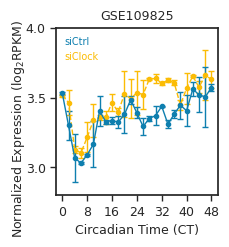

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# -------------------------
# Extract gene
# -------------------------
gene_symbol = "IGF2BP2"

df["gene_name"] = df["gene_name"].astype(str).str.strip().str.upper()
gene_row = df[df["gene_name"] == gene_symbol]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# Organize replicate data
# -------------------------
groups = [
    ("siCtrl", siCtrl_map),
    ("siClock", siClock_map)
]

records = []

for label, mapping in groups:

    for t, cols in mapping.items():

        for col in cols:   # both donors

            val = float(gene_row[col].values[0])

            records.append((label, t, np.log2(val + 1e-6)))

data = pd.DataFrame(records, columns=["group","time","value"])

# -------------------------
# Mean ± SEM
# -------------------------
summary = (
    data
    .groupby(["group","time"])
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# -------------------------
# Colors
# -------------------------
colors = {
    "siCtrl": "#0E7FAF",
    "siClock": "#fbbc05"
}


rhythmic_status = {
    "siCtrl": "rhythmic",
    "siClock": "arrhythmic"
}

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(2.5,2.5))

for g in summary["group"].unique():

    sub = summary[summary["group"] == g].sort_values("time")

    linestyle = "-" if rhythmic_status[g] == "rhythmic" else "--"

    plt.errorbar(
        sub["time"],
        sub["mean"],
        yerr=sub["sem"],
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        color=colors[g],
        linestyle=linestyle
    )

    
# -------------------------
# Styling
# -------------------------
plt.xlabel("Circadian Time (CT)", fontsize=9)
plt.ylabel("Normalized Expression (log$_2$RPKM)", fontsize=9)

plt.xticks(np.arange(0,49,8), fontsize=9)
plt.xlim(-2,50)
plt.ylim(2.8,4)
plt.yticks(np.arange(3,4.5,0.5), fontsize=9)

plt.tick_params(direction="out", length=4, width=1)
plt.tick_params(direction="out", length=4, width=1)

ax = plt.gca()
ax.yaxis.set_label_coords(-0.18, 0.4)

# legend
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g)
    for g in colors
]

legend = plt.legend(
    handles=legend_elements,
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=7
)

for text, g in zip(legend.get_texts(), colors.keys()):
    text.set_color(colors[g])

plt.tight_layout()

plt.title("GSE109825", fontsize=9)




# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE109825_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE109825_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE109825_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)



plt.show()

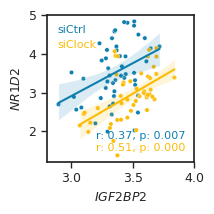

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

# -------------------------
# Extract genes
# -------------------------
igf = df[df["gene_name"]=="IGF2BP2"].iloc[0]
nr1d2 = df[df["gene_name"]=="NR1D2"].iloc[0]

# -------------------------
# Build corr_df
# -------------------------
groups = [
    ("siCtrl", siCtrl_map),
    ("siClock", siClock_map)
]

records = []

for label, mapping in groups:

    for t, cols in mapping.items():

        for col in cols:

            records.append({
                "Igf2bp2": np.log2(float(igf[col]) + 1e-6),
                "Nr1d2": np.log2(float(nr1d2[col]) + 1e-6),
                "Genotype": label
            })

corr_df = pd.DataFrame(records)

# -------------------------
# Colors
# -------------------------
colors = {
    "siCtrl": "#0E7FAF",
    "siClock": "#fbbc05"
}

# r/p annotation position
rpx = 3.2
rpy = 1.8
line_spacing = 0.3

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(2.3,2.3))

sns.scatterplot(
    data=corr_df,
    x="Igf2bp2",
    y="Nr1d2",
    hue="Genotype",
    palette=colors,
    s=10,
    legend=False,
    ax=ax
)

# regression lines
for g in colors:

    sub = corr_df[corr_df["Genotype"] == g]

    sns.regplot(
        data=sub,
        x="Igf2bp2",
        y="Nr1d2",
        scatter=False,
        line_kws={"color":colors[g],"linewidth":1.5},
        ax=ax
    )

# axis
ax.set_xlabel(r"$\it{IGF2BP2}$", fontsize=9)
ax.set_ylabel(r"$\it{NR1D2}$", fontsize=9)


plt.xlim(2.8,4)
plt.xticks(np.arange(3,4.5,0.5), fontsize=9)
ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# legend
legend_elements = [
    Line2D([0],[0],color=colors[g],lw=0,label=g)
    for g in colors
]

legend = ax.legend(
    handles=legend_elements,
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text, g in zip(legend.get_texts(), colors.keys()):
    text.set_color(colors[g])

# r / p values
for i, g in enumerate(colors):

    sub = corr_df[corr_df["Genotype"] == g]

    r,p = pearsonr(sub["Igf2bp2"], sub["Nr1d2"])

    ax.text(
        rpx,
        rpy - i*line_spacing,
        f"r: {r:.2f}, p: {p:.3f}",
        color=colors[g],
        fontsize=8
    )

# plt.title("GSE109825", fontsize=9)

plt.tight_layout()


# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE109825_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE109825_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE109825_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)


plt.show()

## GSE108539

In [239]:
# ----------------------------
# 1️⃣ Load data
# ----------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE108539/GSE108539_norm_reads_count.txt"
df = pd.read_csv(file_path, sep="\t")


In [240]:
print(df.columns)

Index(['Gene_name', 'Intron_15_S1_12.00', 'Intron_15_S2_16.00',
       'Intron_15_S3_20.00', 'Intron_15_S4_00.00', 'Intron_15_S5_04.00',
       'Intron_15_S6_08.00', 'Intron_3_S7_12.00', 'Intron_3_S8_16.00',
       'Intron_3_S9_20.00',
       ...
       'Exon_12_S51_20.00', 'Exon_12_S52_00.00', 'Exon_12_S53_04.00',
       'Exon_12_S54_08.00', 'Exon_1_S55_12.00', 'Exon_1_S56_16.00',
       'Exon_1_S57_20.00', 'Exon_1_S58_00.00', 'Exon_1_S59_04.00',
       'Exon_1_S60_08.00'],
      dtype='object', length=115)


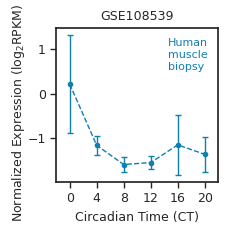

In [269]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

# ----------------------------
# Extract gene
# ----------------------------
gene_id = "ENSG00000073792"

gene_col = df.columns[0]

df["Gene_clean"] = df[gene_col].astype(str).str.split(".").str[0]
gene_row = df[df["Gene_clean"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# ----------------------------
# Extract EXON columns
# ----------------------------
exon_cols = [c for c in df.columns if c.startswith("Exon_")]

records = []

for col in exon_cols:

    time_str = col.split("_")[-1]
    time = int(float(time_str))

    val = float(gene_row[col].values[0])

    if val >= -2:   # remove bad values
        records.append((time, val))

data = pd.DataFrame(records, columns=["time","value"])

# ----------------------------
# Mean ± SEM
# ----------------------------
summary = (
    data
    .groupby("time")
    .agg(mean=("value","mean"),
         sem=("value", lambda x: sem(x, nan_policy="omit")))
    .reset_index()
)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(2.5,2.5))

sub = summary.sort_values("time")

plt.errorbar(
    sub["time"],
    sub["mean"],
    yerr=sub["sem"],
    marker='o',
    markersize=3,
    linewidth=1,
    capsize=2,
    color="#0E7FAF",
    linestyle="--"   # arrhythmic
)

# ----------------------------
# Dark phase
# ----------------------------
# plt.axvspan(12,24,color="lightgrey",alpha=0.5)

# ----------------------------
# Styling
# ----------------------------
plt.xlabel("Circadian Time (CT)", fontsize=9)
plt.ylabel("Normalized Expression (log$_2$RPKM)", fontsize=9)

plt.xticks([0,4,8,12,16,20], fontsize=9)
plt.xlim(-2,22)

plt.yticks(fontsize=9)

plt.tick_params(direction="out", length=4, width=1)


ax = plt.gca()
ax.yaxis.set_label_coords(-0.18, 0.45)

# legend
legend_elements = [
    Line2D([0],[0],color="#0E7FAF",lw=0,label="Human\nmuscle\nbiopsy")
]

legend = plt.legend(
    handles=legend_elements,
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=8
)

for text in legend.get_texts():
    text.set_color("#0E7FAF")

plt.title("GSE108539", fontsize=9)

plt.tight_layout()




# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE108539_igf2bp2_gene_plot.tiff", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE108539_igf2bp2_gene_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE108539_igf2bp2_gene_plot.svg", bbox_inches="tight", transparent=True)


plt.show()

In [56]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE212079/GSE212079_Muscle_SCN_ARC_raw_count.tsv"
df = pd.read_csv(file_path, sep="\t")


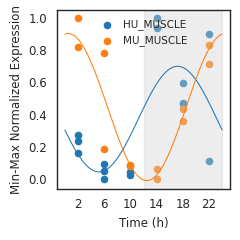

In [61]:

# -------------------------
# 2️⃣ Extract gene (Ensembl ID)
# -------------------------
gene_id = "ENSMUSG00000033581"  # <-- change this
gene_row = df[df["GENE_ID"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Extract only HU_MUSCLE and MU_MUSCLE
# -------------------------
pattern = re.compile(r"(HU|MU)_ZT(\d+)_\d+_MUSCLE")

data_dict = {}

for col in df.columns:
    match = pattern.match(col)
    if match:
        species = match.group(1)        # HU or MU
        time = int(match.group(2))
        group = f"{species}_MUSCLE"

        if group not in data_dict:
            data_dict[group] = []

        value = float(gene_row[col].values[0])
        data_dict[group].append((time, value))

# -------------------------
# 4️⃣ Cosinor model
# -------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# 5️⃣ Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

cmap = plt.get_cmap("tab10")
groups_sorted = sorted(data_dict.keys())

for i, group in enumerate(groups_sorted):

    color = cmap(i)

    times = np.array([x[0] for x in data_dict[group]])
    values = np.array([x[1] for x in data_dict[group]])

    # Sort by time
    order = np.argsort(times)
    times = times[order]
    values = values[order]

    # -------------------------
    # Min-Max normalization (per group)
    # -------------------------
    vmin = values.min()
    vmax = values.max()

    if vmax - vmin == 0:
        norm_values = values
    else:
        norm_values = (values - vmin) / (vmax - vmin)

    # -------------------------
    # Plot normalized raw points
    # -------------------------
    plt.scatter(
        times,
        norm_values,
        color=color,
        s=20,
        alpha=1,
        label=group
    )

    # -------------------------
    # Harmonic fit
    # -------------------------
    try:
        M_guess = norm_values.mean()
        A_guess = (norm_values.max() - norm_values.min()) / 2
        phi_guess = times[np.argmax(norm_values)]

        popt, _ = curve_fit(
            cosinor,
            times,
            norm_values,
            p0=[M_guess, A_guess, phi_guess]
        )

        t_smooth = np.linspace(0, 24, 300)
        y_smooth = cosinor(t_smooth, *popt)

        plt.plot(
            t_smooth,
            y_smooth,
            color=color,
            linewidth=0.75
        )

    except RuntimeError:
        print(f"Fit failed for {group}")

# -------------------------
# Dark phase shading
# -------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("Min-Max Normalized Expression", fontsize=8.5)

all_times = sorted(set([x[0] for g in data_dict.values() for x in g]))
plt.xticks(all_times)

ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.tick_params(axis='both', labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7.5, handlelength=1.5, loc="best")
plt.tight_layout()
plt.show()

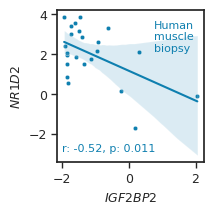

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

sns.set_theme(style="ticks")

# ----------------------------
# Extract genes
# ----------------------------
igf_id = "ENSG00000073792"   # IGF2BP2
nr1d2_id = "ENSG00000126368" # NR1D2

gene_col = df.columns[0]

df["Gene_clean"] = df[gene_col].astype(str).str.split(".").str[0]

igf = df[df["Gene_clean"] == igf_id].iloc[0]
nr1d2 = df[df["Gene_clean"] == nr1d2_id].iloc[0]

# ----------------------------
# Extract EXON columns
# ----------------------------
exon_cols = [c for c in df.columns if c.startswith("Exon_")]

records = []

for col in exon_cols:

    igf_val = float(igf[col])
    nr1d2_val = float(nr1d2[col])

    if igf_val >= -2 and nr1d2_val >= -2:

        records.append({
            "Igf2bp2": igf_val,
            "Nr1d2": nr1d2_val
        })

corr_df = pd.DataFrame(records)

# ----------------------------
# Correlation
# ----------------------------
r, p = pearsonr(corr_df["Igf2bp2"], corr_df["Nr1d2"])



# r/p annotation position
rpx = -2
rpy = -2.9
line_spacing = 0.3

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(2.3,2.3))

sns.scatterplot(
    data=corr_df,
    x="Igf2bp2",
    y="Nr1d2",
    color="#0E7FAF",
    s=10,
    legend=False,
    ax=ax
)

sns.regplot(
    data=corr_df,
    x="Igf2bp2",
    y="Nr1d2",
    scatter=False,
    line_kws={"color":"#0E7FAF","linewidth":1.5},
    ax=ax
)

# axis
ax.set_xlabel(r"$\it{IGF2BP2}$", fontsize=9)
ax.set_ylabel(r"$\it{NR1D2}$", fontsize=9)

ax.tick_params(direction="out", length=4, width=1, labelsize=9)

# r / p annotation
ax.text(
    rpx,
    rpy,
    f"r: {r:.2f}, p: {p:.3f}",
    color="#0E7FAF",
    fontsize=8
)

# legend
legend_elements = [
    Line2D([0],[0],color="#0E7FAF",lw=0,label="Human\nmuscle\nbiopsy")
]

legend = ax.legend(
    handles=legend_elements,
    frameon=False,
    handlelength=0,
    handletextpad=0,
    fontsize=8,loc="upper right"
)

for text in legend.get_texts():
    text.set_color("#0E7FAF")

# plt.title("GSE108539", fontsize=9)

plt.tight_layout()



# save figure
plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE108539_igf2bp2_nr1d2_corr.tiff",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE108539_igf2bp2_nr1d2_corr.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.savefig("../../figures_for_panel/rhythmicity-expressio_and correlation_figs/GSE108539_igf2bp2_nr1d2_corr.svg",
            bbox_inches="tight", transparent=True)




plt.show()